# Rolex Watch Price Analysis - Part 6: K-Means Clustering Analysis
## Market Segmentation Using Unsupervised Learning


## Libraries and settings


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('default')

print(os.getcwd())


/Users/adisaljusi/repos/data_analytics/final


## 1. Load and Prepare Data


In [2]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few records:")
df.head()


Dataset shape: (572, 19)

First few records:


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766756167-1,Rolex,Submariner Date,126613lb,Automatic,Incomplete,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,NEW YORK,14532.0,2020.0,4.0,1,1,1,1
1,1766756169-2,Rolex,GMT-Master II,116713,Automatic,Very Good,Partner Certified Included,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,California,10895.0,NaN,NaN,1,1,1,0
2,1766756171-3,Rolex,GMT-Master II,126711CHNR,Automatic,New,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,Michigan,18314.0,NaN,NaN,1,1,1,1
3,1766756173-4,Rolex,Yacht-Master II,116680,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,Florida,15218.0,2021.0,3.0,1,1,1,1
4,1766756175-5,Rolex,Datejust 41,126334,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,California,11299.0,NaN,NaN,1,1,1,1


## 2. Feature Selection for Clustering

For K-means clustering, we'll use:
- **price**: The watch price (target for understanding segments)
- **age**: How old the watch is
- **has_box**: Binary indicator for original box
- **has_papers**: Binary indicator for papers
- **has_complete_set**: Binary indicator for complete documentation


In [3]:
cluster_features = ['price', 'age', 'has_box', 'has_papers']
df_cluster = df[cluster_features].dropna()

print(f"Data for clustering: {df_cluster.shape[0]:,} samples, {df_cluster.shape[1]} features")
print(f"\nFeatures: {cluster_features}")
print(f"\nBasic statistics:")
df_cluster.describe()


Data for clustering: 388 samples, 4 features

Features: ['price', 'age', 'has_box', 'has_papers']

Basic statistics:


,price,age,has_box,has_papers
count,388.000000,388.000000,388.0,388.0
mean,18402.489691,8.512887,1.0,1.0
std,15153.053682,11.734899,0.0,0.0
min,3068.000000,0.000000,1.0,1.0
25%,10089.750000,1.000000,1.0,1.0
50%,14124.000000,4.000000,1.0,1.0
75%,19860.250000,9.000000,1.0,1.0
max,101722.000000,62.000000,1.0,1.0


## 3. Feature Scaling

K-means clustering is sensitive to the scale of features. We'll use StandardScaler to normalize all features to have mean=0 and std=1.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")


Scaled data shape: (388, 4)

Scaled data statistics:
  Mean: [-1.03010384e-17 -9.15647855e-17  0.00000000e+00  0.00000000e+00]
  Std: [1. 1. 0. 0.]


## 4. Determine Optimal Number of Clusters

We'll use two methods:
1. **Elbow Method**: Look for the "elbow" in the inertia plot
2. **Silhouette Score**: Measure cluster quality


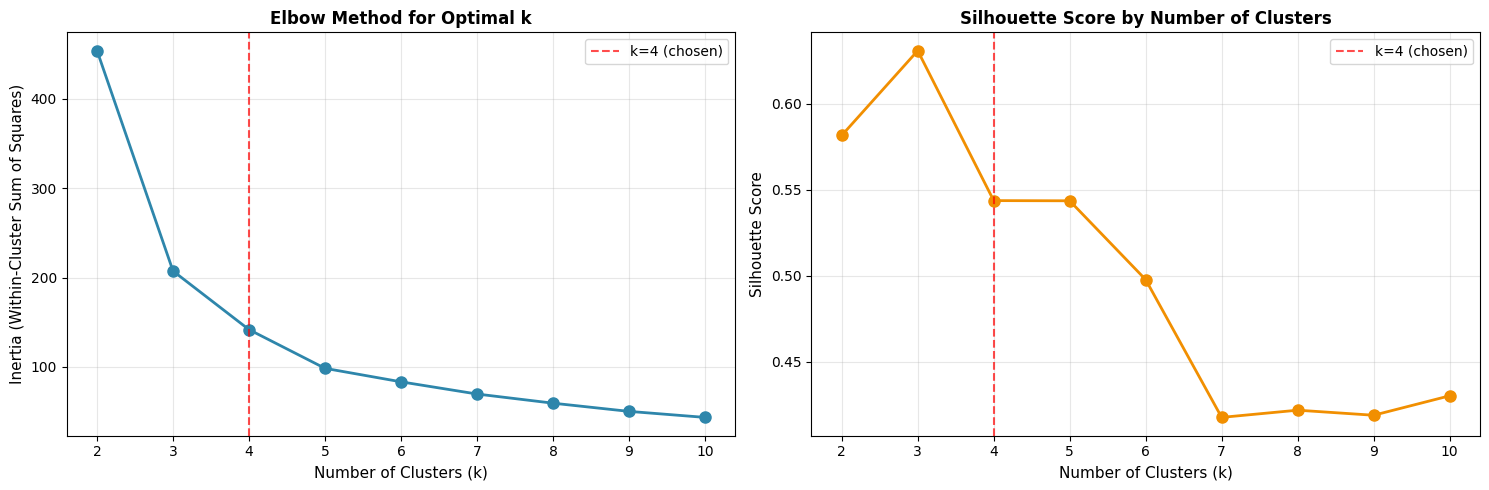

Inertia and Silhouette Scores:
  k=2: Inertia=454.07, Silhouette=0.5817
  k=3: Inertia=207.43, Silhouette=0.6310
  k=4: Inertia=141.83, Silhouette=0.5437
  k=5: Inertia=98.50, Silhouette=0.5436
  k=6: Inertia=83.40, Silhouette=0.4977
  k=7: Inertia=69.74, Silhouette=0.4175
  k=8: Inertia=59.50, Silhouette=0.4217
  k=9: Inertia=50.32, Silhouette=0.4187
  k=10: Inertia=43.59, Silhouette=0.4300


In [5]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#F18F01')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score by Number of Clusters', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Inertia and Silhouette Scores:")
for k, inertia, silh in zip(K_range, inertias, silhouette_scores):
    print(f"  k={k}: Inertia={inertia:,.2f}, Silhouette={silh:.4f}")


### Interpretation

Based on the elbow method and silhouette scores, we'll use **k=4 clusters**. This provides a good balance between:
- Distinct market segments
- Interpretability
- Cluster quality


## 5. Apply K-Means Clustering with k=4


In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters

print(f"Cluster distribution:")
print(df_cluster['cluster'].value_counts().sort_index())
print(f"\nSilhouette score: {silhouette_score(X_scaled, clusters):.4f}")


Cluster distribution:
cluster
0    266
1     51
2     18
3     53
Name: count, dtype: int64

Silhouette score: 0.5437


## 6. Cluster Profiling

Analyze the characteristics of each cluster by examining the mean values of each feature.


In [7]:
cluster_profiles = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_counts = df_cluster.groupby('cluster').size()
cluster_profiles['count'] = cluster_counts

print("Cluster Characteristics (Mean Values):")
print(cluster_profiles)


Cluster Characteristics (Mean Values):
            price    age  has_box  has_papers  count
cluster                                             
0        13372.27   4.80      1.0         1.0    266
1         9544.84  34.94      1.0         1.0     51
2        72993.61   2.83      1.0         1.0     18
3        33631.53   3.64      1.0         1.0     53


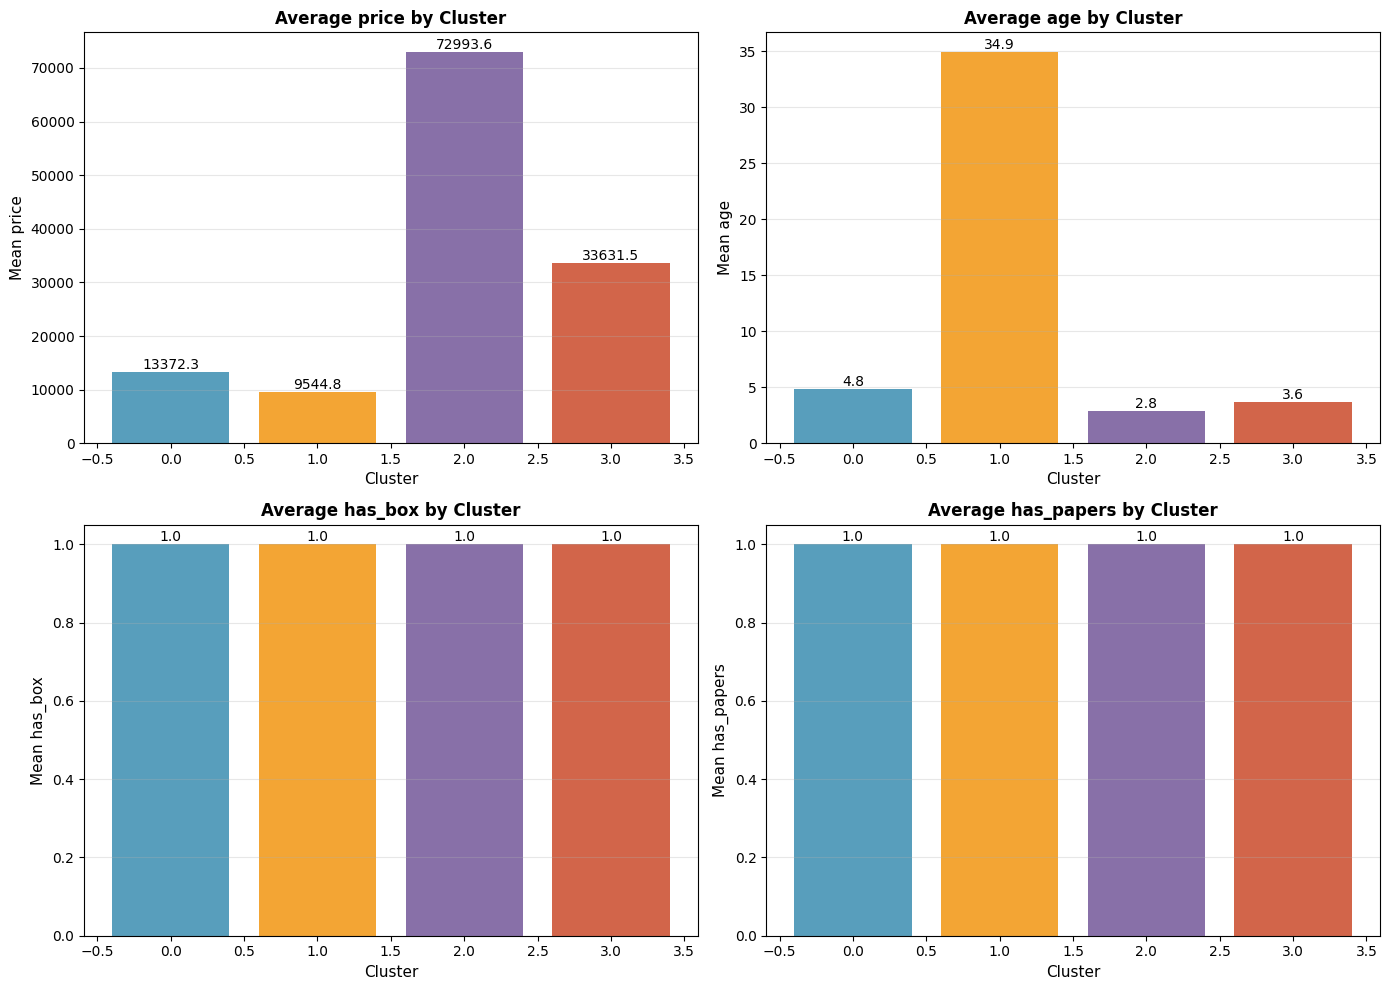

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(cluster_features):
    ax = axes[idx // 2, idx % 2]
    cluster_means = df_cluster.groupby('cluster')[feature].mean()
    colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
    ax.bar(cluster_means.index, cluster_means.values, color=colors, alpha=0.8)
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel(f'Mean {feature}', fontsize=11)
    ax.set_title(f'Average {feature} by Cluster', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for i, v in enumerate(cluster_means.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Cluster Visualization


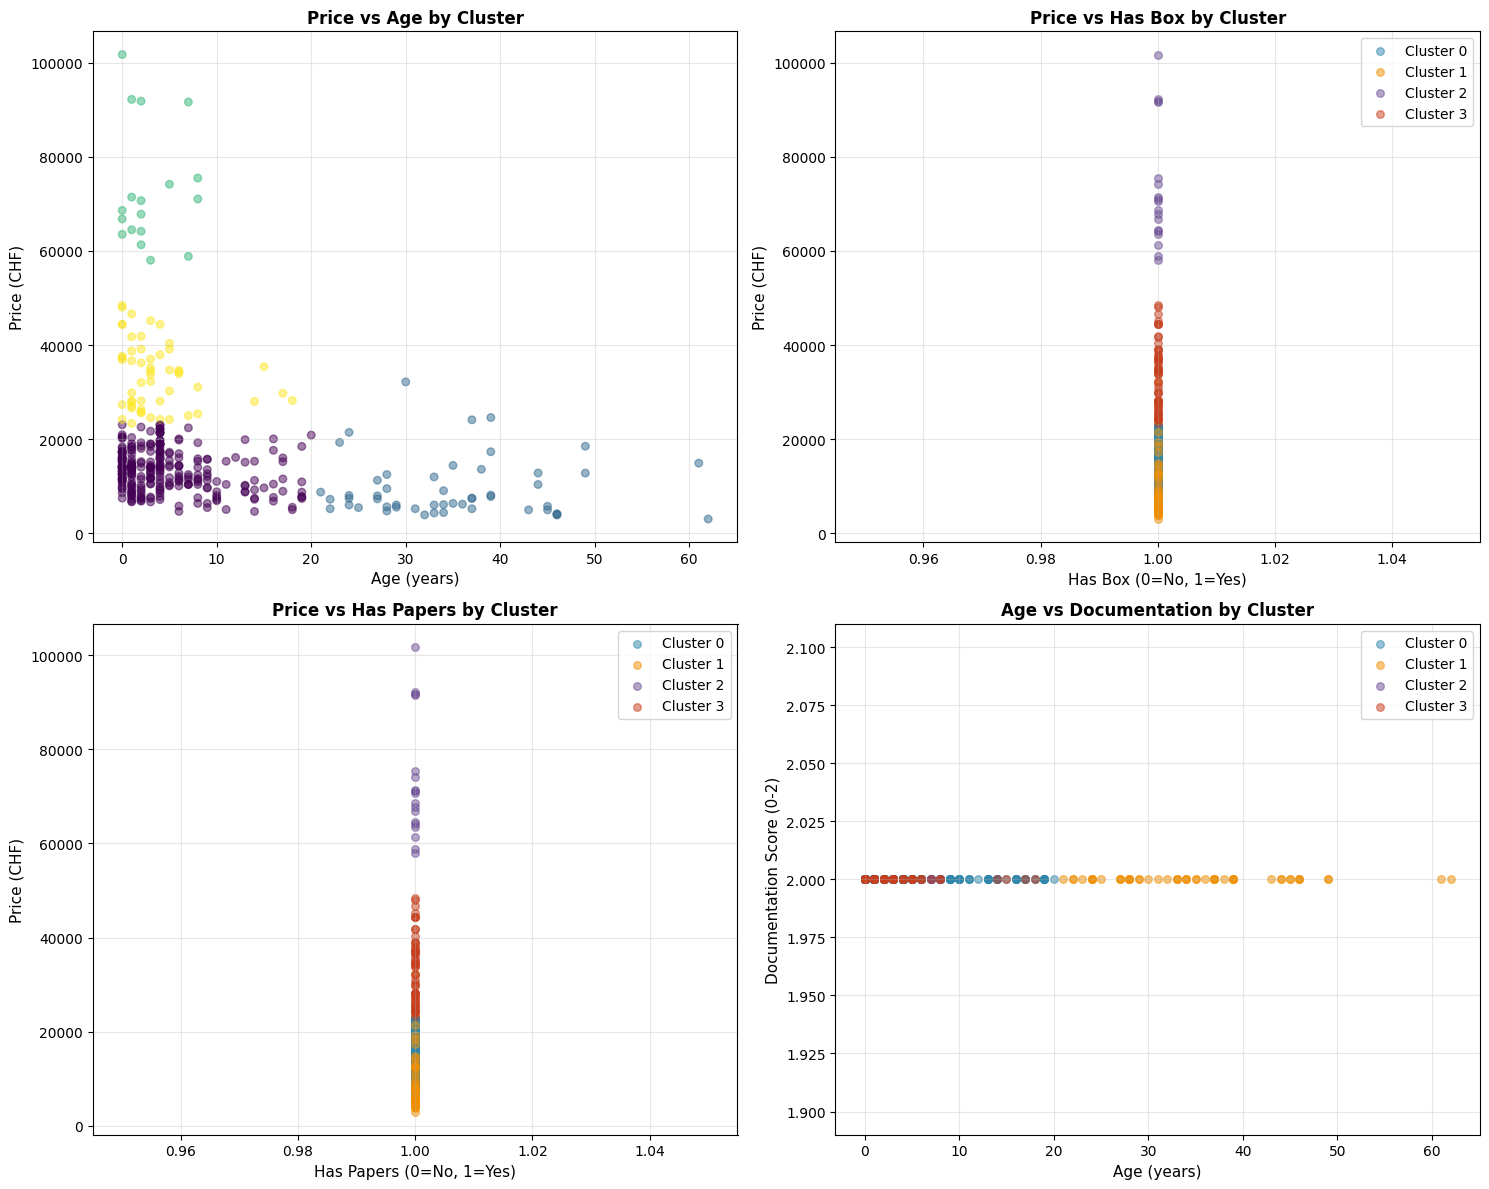

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

axes[0, 0].scatter(df_cluster['age'], df_cluster['price'],
                   c=df_cluster['cluster'], cmap='viridis', alpha=0.5, s=30)
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 0].set_title('Price vs Age by Cluster', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[0, 1].scatter(cluster_data['has_box'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[0, 1].set_xlabel('Has Box (0=No, 1=Yes)', fontsize=11)
axes[0, 1].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 1].set_title('Price vs Has Box by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 0].scatter(cluster_data['has_papers'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 0].set_xlabel('Has Papers (0=No, 1=Yes)', fontsize=11)
axes[1, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[1, 0].set_title('Price vs Has Papers by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 1].scatter(cluster_data['age'], cluster_data['has_box'] + cluster_data['has_papers'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 1].set_xlabel('Age (years)', fontsize=11)
axes[1, 1].set_ylabel('Documentation Score (0-2)', fontsize=11)
axes[1, 1].set_title('Age vs Documentation by Cluster', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


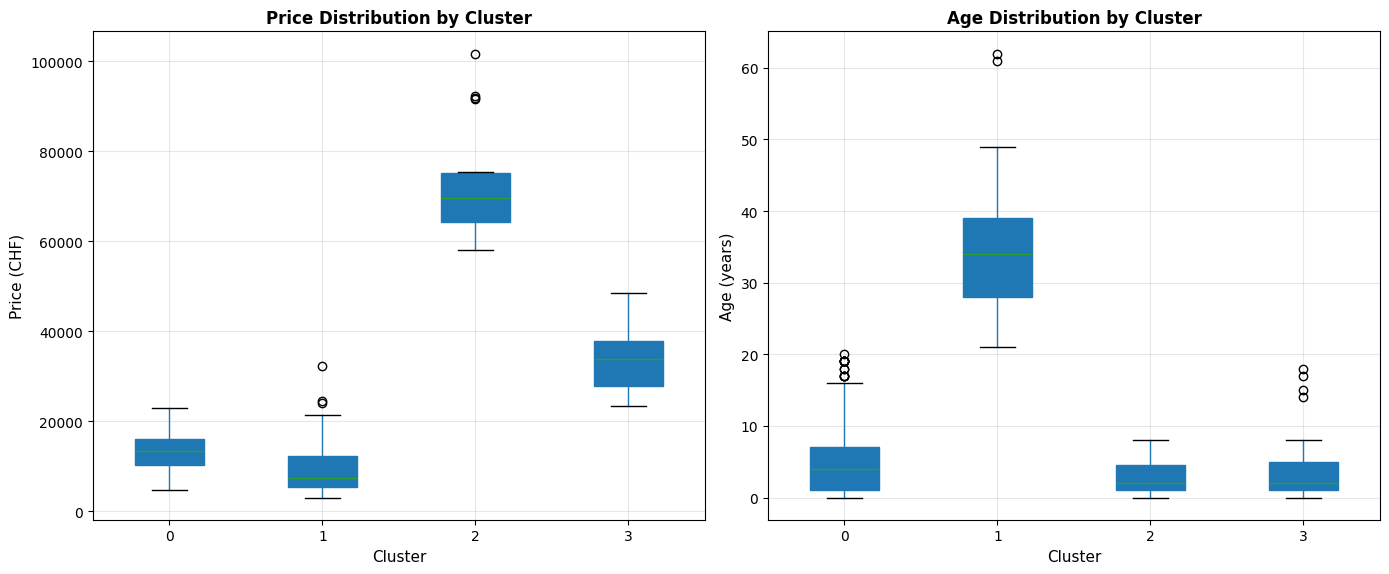

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_cluster.boxplot(column='price', by='cluster', ax=axes[0], patch_artist=True)
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Price (CHF)', fontsize=11)
axes[0].set_title('Price Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[0].grid(alpha=0.3)

df_cluster_with_age = df_cluster[df_cluster['age'].notna()]
df_cluster_with_age.boxplot(column='age', by='cluster', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Age (years)', fontsize=11)
axes[1].set_title('Age Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Business Interpretation of Clusters

Based on the cluster profiles, we can identify distinct market segments:


In [11]:
# Add cluster back to original dataframe
df_with_clusters = df.copy()
df_with_clusters['cluster'] = np.nan
df_with_clusters.loc[df_cluster.index, 'cluster'] = clusters

# Detailed cluster analysis
print("="*70)
print("DETAILED CLUSTER PROFILES")
print("="*70)

for i in range(4):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    print(f"\n{'='*70}")
    print(f"CLUSTER {i} PROFILE")
    print(f"{'='*70}")
    print(f"\nSize: {len(cluster_data):,} watches ({len(cluster_data)/len(df_with_clusters)*100:.1f}% of total)")

    print(f"\nPrice Characteristics:")
    print(f"  Average Price: {cluster_data['price'].mean():,.2f} CHF")
    print(f"  Median Price: {cluster_data['price'].median():,.2f} CHF")
    print(f"  Price Range: {cluster_data['price'].min():,.2f} - {cluster_data['price'].max():,.2f} CHF")

    print(f"\nAge Characteristics:")
    if cluster_data['age'].notna().sum() > 0:
        print(f"  Average Age: {cluster_data['age'].mean():.1f} years")
        print(f"  Median Age: {cluster_data['age'].median():.0f} years")

    print(f"\nDocumentation:")
    print(f"  Has Box: {cluster_data['has_box'].mean()*100:.1f}%")
    print(f"  Has Papers: {cluster_data['has_papers'].mean()*100:.1f}%")
    print(f"  Complete Set: {cluster_data['has_complete_set'].mean()*100:.1f}%")

    print(f"\nMost Common Characteristics:")
    print(f"  Condition: {cluster_data['condition_category'].mode()[0] if len(cluster_data['condition_category'].mode()) > 0 else 'N/A'}")
    print(f"  Material: {cluster_data['material_category'].mode()[0] if len(cluster_data['material_category'].mode()) > 0 else 'N/A'}")
    print(f"  Seller Type: {cluster_data['seller_type'].mode()[0] if len(cluster_data['seller_type'].mode()) > 0 else 'N/A'}")


DETAILED CLUSTER PROFILES

CLUSTER 0 PROFILE

Size: 266 watches (46.5% of total)

Price Characteristics:
  Average Price: 13,372.27 CHF
  Median Price: 13,432.50 CHF
  Price Range: 4,679.00 - 23,070.00 CHF

Age Characteristics:
  Average Age: 4.8 years
  Median Age: 4 years

Documentation:
  Has Box: 100.0%
  Has Papers: 100.0%
  Complete Set: 100.0%

Most Common Characteristics:
  Condition: Very Good
  Material: Steel
  Seller Type: Professional dealer

CLUSTER 1 PROFILE

Size: 51 watches (8.9% of total)

Price Characteristics:
  Average Price: 9,544.84 CHF
  Median Price: 7,423.00 CHF
  Price Range: 3,068.00 - 32,193.00 CHF

Age Characteristics:
  Average Age: 34.9 years
  Median Age: 34 years

Documentation:
  Has Box: 100.0%
  Has Papers: 100.0%
  Complete Set: 100.0%

Most Common Characteristics:
  Condition: Very Good
  Material: Steel
  Seller Type: Professional dealer

CLUSTER 2 PROFILE

Size: 18 watches (3.1% of total)

Price Characteristics:
  Average Price: 72,993.61 CHF
  

## 9. Market Segment Naming and Interpretation

Based on the cluster characteristics, we can name our market segments:


In [12]:
# Determine segment names based on characteristics
segment_names = {}
segment_descriptions = {}

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    avg_price = cluster_data['price'].mean()
    avg_age = cluster_data['age'].mean()
    doc_score = cluster_data['has_box'].mean() + cluster_data['has_papers'].mean()

    if avg_price > df_cluster['price'].quantile(0.75):
        if doc_score > 1.5:
            segment_names[i] = "Ultra-Luxury Premium"
            segment_descriptions[i] = "High-value watches with excellent documentation"
        else:
            segment_names[i] = "High-End Collectibles"
            segment_descriptions[i] = "Expensive watches, varying documentation"
    elif avg_price > df_cluster['price'].median():
        if doc_score > 1.0:
            segment_names[i] = "Premium Well-Documented"
            segment_descriptions[i] = "Mid-to-high price range with good documentation"
        else:
            segment_names[i] = "Premium Market"
            segment_descriptions[i] = "Mid-to-high price range, mixed documentation"
    else:
        if doc_score > 1.0:
            segment_names[i] = "Entry-Level Complete"
            segment_descriptions[i] = "Lower prices with good documentation"
        else:
            segment_names[i] = "Value Segment"
            segment_descriptions[i] = "Entry-level pricing, basic documentation"

print("="*70)
print("MARKET SEGMENT SUMMARY")
print("="*70)

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    print(f"\nCluster {i}: {segment_names[i]}")
    print(f"  {segment_descriptions[i]}")
    print(f"  Size: {len(cluster_data):,} watches")
    print(f"  Avg Price: {cluster_data['price'].mean():,.0f} CHF")
    print(f"  Avg Age: {cluster_data['age'].mean():.1f} years")
    print(f"  Documentation Score: {(cluster_data['has_box'].mean() + cluster_data['has_papers'].mean()):.2f}/2")


MARKET SEGMENT SUMMARY

Cluster 0: Entry-Level Complete
  Lower prices with good documentation
  Size: 266 watches
  Avg Price: 13,372 CHF
  Avg Age: 4.8 years
  Documentation Score: 2.00/2

Cluster 1: Entry-Level Complete
  Lower prices with good documentation
  Size: 51 watches
  Avg Price: 9,545 CHF
  Avg Age: 34.9 years
  Documentation Score: 2.00/2

Cluster 2: Ultra-Luxury Premium
  High-value watches with excellent documentation
  Size: 18 watches
  Avg Price: 72,994 CHF
  Avg Age: 2.8 years
  Documentation Score: 2.00/2

Cluster 3: Ultra-Luxury Premium
  High-value watches with excellent documentation
  Size: 53 watches
  Avg Price: 33,632 CHF
  Avg Age: 3.6 years
  Documentation Score: 2.00/2


## 10. Business Insights and Recommendations

Based on the clustering analysis:

### Key Findings:
1. **Market is segmented** into distinct price-documentation-age groups
2. **Documentation matters** across all segments but especially in premium segments
3. **Age relationships** vary by segment - some clusters favor newer watches, others vintage
4. **Clear price tiers** exist in the luxury watch market

### Business Recommendations:
1. **For Sellers**:
   - Preserve original documentation to move into higher-value segments
   - Understand which segment your watch belongs to for pricing strategy
   - Complete sets command premiums in all segments

2. **For Buyers**:
   - Understand market segments to identify value opportunities
   - Documentation completeness strongly correlates with segment
   - Age-price relationships differ by segment

3. **For Dealers**:
   - Stock balance across segments for portfolio diversification
   - Premium segments show higher documentation rates
   - Consider segment-specific marketing strategies


## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)


In [15]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')


-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-26 20:02:55
Python Version: 3.11.13
-----------------------------------
